In [72]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad


import xobjects as xo
import xtrack as xt
import xpart as xp
import xcoll as xc

import pandas as pd

# Make a context and get a buffer
context = xo.ContextCpu()         # For CPU
# context = xo.ContextCupy()      # For CUDA GPUs
# context = xo.ContextPyopencl()  # For OpenCL GPUs

In [73]:
num_part = int(10000)
x_init = 0.002 * np.ones(num_part)
px_init = np.zeros(num_part)
y_init   = np.zeros(num_part)
py_init  = np.zeros(num_part)

def initialize_particles(context, num_particles=num_part):
    return xp.Particles(
        _context=context,
        x=x_init,  # Replace with actual particle positions
        px=px_init,  # Replace with actual momenta
        y=y_init,
        py=py_init,
        delta=0,
        p0c=4e11
    )
    

In [74]:
# Define the crystal properties (initial values)
bending_angle=149e-6
material = xc.materials.SiliconCrystal
width = 0.002
height = 0.05
side = '+'
miscut = 0.0
lattice = 'strip'
jaw = 0.001

In [75]:
# Dataframe to store particle tracking information
columns = ['iteration', 'particle_id', 'x', 'px']
tracking_data = pd.DataFrame(columns=columns)

In [76]:
min_length = 4
max_length = 40
steps = 1
# Define the range of bending angles to iterate over
lengths = [i * 1e-4 for i in range(min_length, max_length, steps)] #Example: from 0.5 mm to 4 mm in steps of 0.1 mm

In [77]:
# List to collect all tracking data
tracking_data_list = []

# Loop over bending angles
for iteration, length in enumerate(lengths):
    # Create the crystal with the current bending angle
    coll = xc.EverestCrystal(
        length=length,
        material=material,
        bending_angle=bending_angle,
        width=width,
        height=height,
        side=side,
        miscut=miscut,
        lattice=lattice,
        jaw=jaw,
        _context=context
    )
    
    # Initialize a new beam of particles for this iteration
    part = initialize_particles(context)
    
    # Track particles through the crystal
    coll.track(part)  # Updates the particle states in place
    
    # Collect particle data for this iteration
    for i in range(len(part.x)):
        tracking_data_list.append({
            'iteration': iteration,
            'particle_id': i,
            'x': part.x[i],
            'px': part.px[i],
        })

# Convert the collected data into a DataFrame
tracking_data = pd.DataFrame(tracking_data_list)


In [78]:
tracking_data


,iteration,particle_id,x,px
0,0,0,0.002,0.000152
1,0,1,0.002,-0.000002
2,0,2,0.002,0.000149
3,0,3,0.002,0.000150
4,0,4,0.002,0.000149
...,...,...,...,...
359995,35,9995,0.002,-0.000006
359996,35,9996,0.002,-0.000005
359997,35,9997,0.002,-0.000012
359998,35,9998,0.002,-0.000004


In [79]:
# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2))



# Placeholder for efficiencies
efficiencies = []

# Loop over iterations
for iteration in tracking_data['iteration'].unique():
    # Filter data for the current iteration
    iteration_data = tracking_data[tracking_data['iteration'] == iteration]
    px_values = iteration_data['px']
    
    # Generate the histogram data for plotting and fitting
    counts, bin_edges = np.histogram(px_values, bins=2000, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Create histogram
    hist, bin_edges = np.histogram(px_values, bins=np.arange(min(px_values), max(px_values) + bin_width, bin_width))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Initial guesses for Gaussian parameters (amplitude, mean, stddev)
    initial_guess = [max(hist), np.mean(px_values), np.std(px_values)]
    
    # Fit the histogram with the Gaussian
    try:
        popt, _ = curve_fit(gaussian, bin_centers, hist, p0=initial_guess)
    except RuntimeError:
        print(f"Gaussian fit failed for iteration {iteration}")
        efficiencies.append(None)
        continue

    # Calculate efficiency
    amplitude, mean, stddev = popt
    integral_of_fit = amplitude * stddev * np.sqrt(2 * np.pi)  # Integral of the Gaussian
    efficiency = abs(integral_of_fit / (num_part * bin_width))
    efficiencies.append(efficiency)
    
crystal_length = (min_length + tracking_data['iteration'].unique() * steps)*10e-2   
# Save efficiencies to DataFrame for analysis
efficiency_data = pd.DataFrame({
    'Crystal length (mm)': crystal_length,
    'efficiency': efficiencies
})

# Display the efficiency data
print(efficiency_data)

    Crystal length (mm)  efficiency
0                   0.4    0.385812
1                   0.5    0.633257
2                   0.6    0.684956
3                   0.7    0.707968
4                   0.8    0.730507
5                   0.9    0.746882
6                   1.0    0.752250
7                   1.1    0.762727
8                   1.2    0.763363
9                   1.3    0.783095
10                  1.4    0.783277
11                  1.5    0.784296
12                  1.6    0.787419
13                  1.7    0.795108
14                  1.8    0.793880
15                  1.9    0.788526
16                  2.0    0.791648
17                  2.1    0.799088
18                  2.2    0.801521
19                  2.3    0.799231
20                  2.4    0.806057
21                  2.5    0.792134
22                  2.6    0.801954
23                  2.7    0.802522
24                  2.8    0.800056
25                  2.9    0.802743
26                  3.0    0

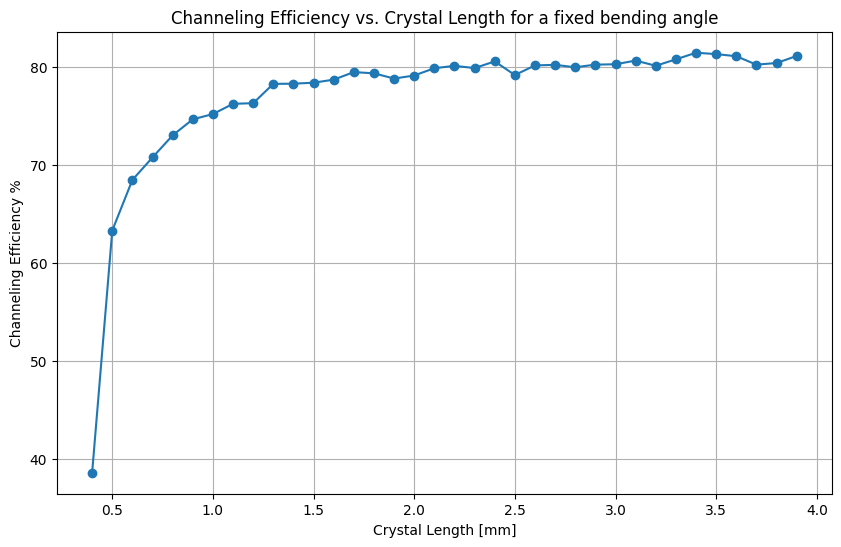

In [80]:
# Ensure efficiencies and bending angles are in the same order
efficiency_data['crystal_length'] = [angle for angle in lengths] 

# Plot Channeling Efficiency vs Bending Angle
plt.figure(figsize=(10, 6))
plt.plot(efficiency_data['crystal_length']*10e2, efficiency_data['efficiency'] * 100, marker='o', linestyle='-')

# Customize the plot
plt.title('Channeling Efficiency vs. Crystal Length for a fixed bending angle')
plt.xlabel(r'Crystal Length [mm]')
plt.ylabel('Channeling Efficiency %')
plt.grid(True)
plt.show()